In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
#from utils import (load_czi_file)
from napari import viewer
from skimage import filters
#from image_processing import create_binary_mask, watershed_segmentation
from skimage.morphology import disk, closing, opening, erosion, dilation
from skimage.measure import label
from scipy.ndimage import median_filter
from scripts.circularity import circ_filter
import scripts.circle_fitting as circle_fitting
from scripts.image_processing import watershed_segmentation
from scripts.image_processing import create_binary_mask
from scripts.circularity import circ_filter
from skimage.measure import regionprops
from xml.etree import ElementTree as ET
from aicsimageio import AICSImage
from scipy.optimize import curve_fit
from scipy.ndimage import binary_fill_holes

In [2]:
from aicsimageio import AICSImage
#rep1
img = AICSImage('/Users/taskina/Lab/raw/confocal/2026_02_04_Will_paper/Will_droplet/rep1/Part2_12_36_hours/Experiment-306.czi')
#rep2
#img2 = AICSImage('/Users/taskina/Lab/raw/confocal/2026_02_04_Will_paper/Will_droplet/rep2/241130/Part1_overnight_until_morning/Experiment-128.czi')
# Check dimensions and scenes
print(img.dims)           # e.g., STCZYX
#print(img2.dims)

<Dimensions [T: 74, C: 2, Z: 14, Y: 2048, X: 2048]>


In [6]:
img.set_scene(img.scenes[3])
I = img.data[:,0,7,:,:]
footprint_3d = disk(5)[np.newaxis, :, :]
se = disk(1)
min_d_ws = 6
disk_ws = 8

In [4]:
view = viewer.Viewer()
view.add_image(I, name='Original time stack z=7, scene 3')
I_median_filter = median_filter(I, footprint=footprint_3d)
view.add_image(I_median_filter, name='Median filtered')
I_bin = create_binary_mask(I_median_filter, method='threshold_li')[0]
view.add_image(I_bin, name='Binary mask')

<Image layer 'Binary mask' at 0x53916ee90>

In [5]:
# Fill the holes
filled = np.array([binary_fill_holes(frame) for frame in I_bin])
# Vacuoles = filled - original
vacuole_mask = filled & ~I_bin
view.add_labels(vacuole_mask.astype(np.uint8), name='vacuoles')
vacuole_opened = np.array([opening(frame, footprint=disk(5)) for frame in vacuole_mask])
vacuole_opened_closed = np.array([closing(frame, footprint=se) for frame in vacuole_mask])
view.add_labels(vacuole_opened_closed.astype(np.uint8), name='vacuoles opened closed')

<Labels layer 'vacuoles opened closed' at 0x5395e2ad0>

In [7]:
min_d_ws = 6
disk_ws = 8

In [12]:
radii_rep1 = [[]for _ in range(len(vacuole_opened_closed))]

I_v_labels = label(vacuole_opened_closed, connectivity=1, background=0)
view.add_labels(I_v_labels, name=f'Labels')
I_labels_ws = [watershed_segmentation(frame, min_distance=min_d_ws, disk_size=disk_ws) for frame in I_v_labels]
I_labels_ws = [circ_filter(frame, circularity_filter='manual', circularity_threshold=0.7, size_filter='none')[0]
        for frame in I_labels_ws]
view.add_labels(np.array(I_labels_ws), name='Watershed segmented')

#circle fitting
circles_per_t = [circle_fitting.fit_circles_area_based(I_labels_ws[t]) for t in range(len(I_labels_ws))]
circle_labels = []

#circle visualisation
for t, circles in enumerate(circles_per_t):
    r_t = []
    for cy, cx, r, label_id in circles:
        r_t.append(r)
        circle_labels.append(np.array([
            [t, cy - r, cx - r],
            [t, cy - r, cx + r],
            [t, cy + r, cx + r],
            [t, cy + r, cx - r],
        ]))
    radii_rep1[t]+= r_t
view.add_shapes(
    circle_labels,
    shape_type='ellipse',
    edge_color='red',
    face_color='transparent',
    edge_width=1,
    name=f'circle_fits'
    )

<Shapes layer 'circle_fits' at 0x539a9b8c0>

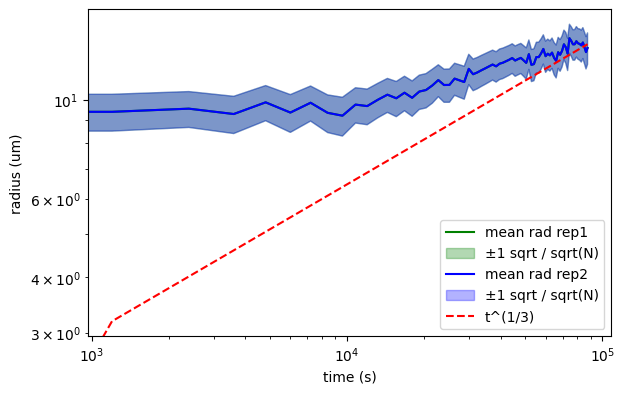

In [17]:
plt.figure(figsize=(6,4))

dx = img.physical_pixel_sizes.X
delta_t = 1200

t = np.arange(74)*1200
t_rip = [0.3*t**(1/3) for t in t]

r_means = [np.mean(r*np.array(dx)) for r in radii_rep1]
r_stds = [np.std(r*np.array(dx)) for r in radii_rep1]
N = [len(r) for r in radii_rep1]

plt.plot(t[:len(r_means)], r_means, color='green', label='mean rad rep1')
plt.fill_between(t[:len(r_means)], np.array(r_means)-np.array(r_stds)/np.sqrt(N),
                    np.array(r_means)+np.array(r_stds)/np.sqrt(N),
                    alpha=0.3, color='green', label='±1 sqrt / sqrt(N)')


plt.plot(t[:len(r_means)], r_means, color='blue', label='mean rad rep2')
plt.fill_between(t[:len(r_means)], np.array(r_means)-np.array(r_stds)/np.sqrt(N),
                    np.array(r_means)+np.array(r_stds)/np.sqrt(N),
                    alpha=0.3, color='blue', label='±1 sqrt / sqrt(N)')

plt.plot(t[:], t_rip[:], color='r', linestyle='--',label='t^(1/3)')

plt.xlabel('time (s)')
plt.ylabel('radius (um)')
plt.legend()
plt.tight_layout()
plt.xscale('log')
plt.yscale('log')